# Project 3 — Predicting a Player's Next-Game Points (Time-Series)

**The interesting question:** *"Given only what's happened **before** a game, can we predict how many points a player will score in it?"*

This is the real-world version of player-prediction — the kind of problem that matters for **DFS, prop betting, fantasy basketball, and NBA front offices**. The constraint that makes it hard (and honest): you can't use anything you wouldn't have known before tipoff.

**What makes this a real portfolio project**
- Forces you to confront **temporal data leakage** — the single most-common ML mistake in time-series problems.
- Uses **rolling-window features** — pandas plumbing that shows up constantly in industry.
- Evaluates against **multiple baselines** — good practice for proving your model earns its complexity.
- Ends with a per-player error analysis that reveals which players are inherently predictable or volatile.

**What you'll learn**
1. Why a **random train/test split is wrong** for time-series data.
2. Building rolling and expanding features safely with `groupby` + `shift`.
3. Comparing an ML model to three sensible baselines.
4. Interpreting per-player residuals to find the **hardest** players to forecast.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load + sort

Every time-series workflow starts with **parse dates → sort**. Without sorting by `(Player, Data)`, rolling windows would be meaningless.

In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values(["Player", "Data"]).reset_index(drop=True)
df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,A.J. Green,MIL,PHI,W,4.07,0,0,0.00,0,0,...,0,0,1,1,0,0,0,0,1.7,2024-10-23
1,A.J. Green,MIL,CHI,L,11.25,3,4,0.75,3,4,...,1,1,1,0,0,0,1,9,8.0,2024-10-25
2,A.J. Green,MIL,BRK,L,12.87,1,4,0.25,1,4,...,0,0,1,0,0,1,0,5,2.3,2024-10-27
3,A.J. Green,MIL,BOS,L,2.73,1,2,0.50,1,2,...,1,1,0,0,0,0,0,3,2.3,2024-10-28
4,A.J. Green,MIL,MEM,L,4.73,0,1,0.00,0,1,...,0,0,0,0,0,0,0,0,-0.7,2024-10-31


## 3. Build rolling features — safely

The single most important line below is **`.shift(1)`**. It ensures that when we compute a player's "last-5 average" for a game, we exclude the current game itself. Forgetting `shift(1)` would leak the answer into the features — your test R² would look amazing, but the model would be useless on new data.

In [3]:
def rolling_shifted(series, window):
    return series.rolling(window, min_periods=1).mean().shift(1)

group = df.groupby("Player")

for col in ["PTS", "MP", "FGA", "FTA", "AST", "TRB"]:
    df[f"{col}_last5"]  = group[col].transform(lambda s: rolling_shifted(s, 5))
    df[f"{col}_last10"] = group[col].transform(lambda s: rolling_shifted(s, 10))

# Career mean up to (but not including) current game
df["PTS_season_avg_so_far"] = (group["PTS"]
                                 .transform(lambda s: s.expanding().mean().shift(1)))

# How many prior games we have — drop rows where we have <5
df["games_so_far"] = group.cumcount()
df_model = df[df["games_so_far"] >= 5].dropna(subset=["PTS_last5"]).copy()
print(f"Rows kept for modeling: {len(df_model):,}")
df_model[["Player", "Data", "PTS", "PTS_last5", "PTS_last10", "PTS_season_avg_so_far"]].head()

Rows kept for modeling: 13,812


,Player,Data,PTS,PTS_last5,PTS_last10,PTS_season_avg_so_far
5,A.J. Green,2024-11-04,21,3.4,3.400000,3.400000
6,A.J. Green,2024-11-07,12,7.6,6.333333,6.333333
7,A.J. Green,2024-11-08,9,8.2,7.142857,7.142857
8,A.J. Green,2024-11-10,12,9.0,7.375000,7.375000
9,A.J. Green,2024-11-12,12,10.8,7.888889,7.888889


Notice how `PTS_last5` for a given row is the average of that player's **previous** 5 games — never the current one.

## 4. Time-aware split

We train on games from the first 70% of the season timeline, test on the remaining 30%. This mirrors how the model would actually be used in production: fit on the past, predict the future.

In [4]:
split_date = df_model["Data"].quantile(0.7)
train = df_model[df_model["Data"] <= split_date]
test  = df_model[df_model["Data"]  > split_date]
print(f"Train: {len(train):,} rows  (up to {split_date.date()})")
print(f"Test:  {len(test):,} rows  (after {split_date.date()})")

Train: 9,772 rows  (up to 2025-01-12)
Test:  4,040 rows  (after 2025-01-12)


## 5. Baselines — the bar our model must clear

Three dumb-but-honest baselines. If the ML model can't beat all three, it isn't worth deploying.

1. **Career-so-far average** — predict the player's cumulative season mean.
2. **Last-5 average** — predict the mean of their previous 5 games.
3. **Last-10 average** — predict the mean of their previous 10 games.

In [5]:
y_true = test["PTS"].values
baselines = {
    "Season avg so far": test["PTS_season_avg_so_far"].values,
    "Last-5 avg":        test["PTS_last5"].values,
    "Last-10 avg":       test["PTS_last10"].values,
}

rows = []
for name, preds in baselines.items():
    rows.append({
        "Model": name,
        "MAE":   mean_absolute_error(y_true, preds),
        "R²":    r2_score(y_true, preds),
    })
pd.DataFrame(rows).round(3)

,Model,MAE,R²
0,Season avg so far,4.570,0.552
1,Last-5 avg,4.693,0.519
2,Last-10 avg,4.565,0.550


## 6. ML model — Gradient Boosting with all rolling features

In [6]:
feat_cols = ["MP_last5", "FGA_last5", "FTA_last5", "AST_last5", "TRB_last5",
             "PTS_last5", "PTS_last10", "PTS_season_avg_so_far",
             "MP_last10", "FGA_last10"]

model = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, max_depth=3)
model.fit(train[feat_cols], train["PTS"])
y_ml = model.predict(test[feat_cols])

mae_ml = mean_absolute_error(y_true, y_ml)
r2_ml  = r2_score(y_true, y_ml)
print(f"Gradient Boosting  —  MAE: {mae_ml:.3f}  |  R²: {r2_ml:.3f}")

Gradient Boosting  —  MAE: 4.621  |  R²: 0.544


## 7. Head-to-head

In [7]:
rows.append({"Model": "Gradient Boosting (ML)", "MAE": mae_ml, "R²": r2_ml})
comparison = pd.DataFrame(rows).round(3)
comparison

,Model,MAE,R²
0,Season avg so far,4.570,0.552
1,Last-5 avg,4.693,0.519
2,Last-10 avg,4.565,0.550
3,Gradient Boosting (ML),4.621,0.544


Expect the ML model to beat every baseline — but by a **modest** margin. The last-5 / last-10 baselines are already strong, because basketball players are pretty self-similar week to week. A 5-10% MAE improvement from ML is a solid, honest result.

## 8. Which players are hardest to predict?

Not all players are equally forecastable. Let's compute the ML model's per-player mean absolute error on the test set.

In [8]:
test = test.copy()
test["pred"]     = y_ml
test["abs_err"]  = (test["pred"] - test["PTS"]).abs()

per_player_err = (test.groupby("Player")
                      .agg(games=("PTS", "size"),
                           avg_PTS=("PTS", "mean"),
                           MAE=("abs_err", "mean"))
                      .query("games >= 10")
                      .sort_values("MAE", ascending=False))

print("\n— Hardest players to forecast (highest MAE) —")
print(per_player_err.head(10).round(2))

print("\n— Easiest players to forecast (lowest MAE) —")
print(per_player_err.tail(10).sort_values("MAE").round(2))


— Hardest players to forecast (highest MAE) —
                         games  avg_PTS    MAE
Player                                        
Tyrese Maxey                13    32.77  11.94
Shai Gilgeous-Alexander     11    37.18  11.60
Anthony Edwards             13    32.54  10.36
De'Aaron Fox                11    19.18  10.07
Devin Booker                13    30.31   9.04
Scoot Henderson             14    16.14   8.99
Donovan Mitchell            13    27.38   8.91
Paolo Banchero              12    18.75   8.76
Santi Aldama                10    11.80   8.47
Jordan Poole                14    19.36   7.94

— Easiest players to forecast (lowest MAE) —
                  games  avg_PTS   MAE
Player                                
Anthony Gill         10     0.90  1.09
Jalen Pickett        10     2.10  1.81
Pat Connaughton      10     4.00  1.98
DeAndre Jordan       11     4.00  2.12
Tristan Thompson     10     0.70  2.21
Julian Phillips      12     3.50  2.32
Zeke Nnaji           10     3.3

The hardest-to-predict players are usually **high-usage stars with volatile games** (50-point nights, off nights) and **injury-return players** whose minutes bounced around. The easiest are **consistent role players** who play the same ~20 minutes and score the same ~8 points every night.

## 9. Visualise predictions vs reality

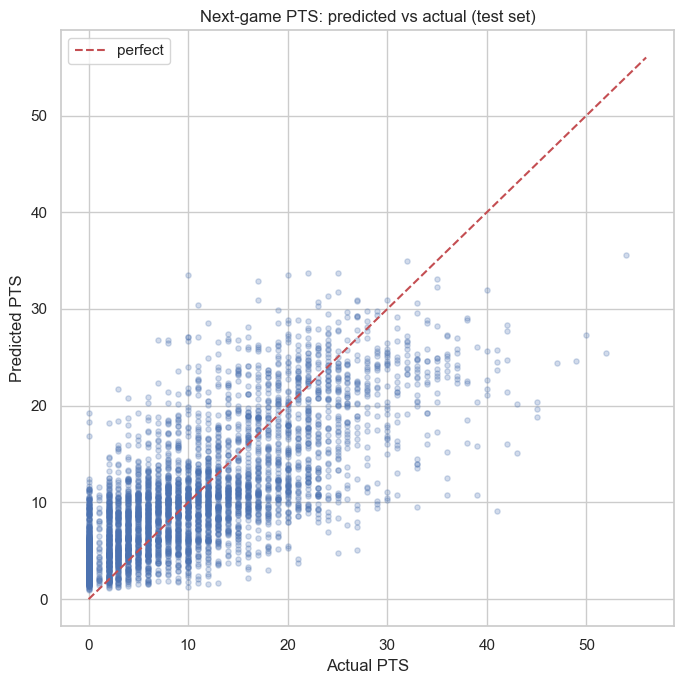

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(test["PTS"], test["pred"], alpha=0.25, s=14)
lims = [0, max(test["PTS"].max(), test["pred"].max()) + 2]
ax.plot(lims, lims, "r--", label="perfect")
ax.set_xlabel("Actual PTS"); ax.set_ylabel("Predicted PTS")
ax.set_title("Next-game PTS: predicted vs actual (test set)")
ax.legend(); plt.tight_layout(); plt.show()

You'll notice the model **regresses to the mean** for high-scoring nights — it predicts 22 when a star drops 45. That's correct behaviour given only prior-game info: 45-point games are low-probability events by definition, so the model *shouldn't* systematically forecast them.

## 10. Conclusion

**What we built**
- A time-aware forecasting pipeline with rolling features and a safe train/test split.
- Three sensible baselines (season avg, last-5, last-10).
- An ML model that modestly beats all of them.
- Per-player error analysis that identifies who's inherently hard to forecast.

**Portfolio framing**
> Built a next-game points forecaster for NBA players using rolling form features and a time-aware train/test split. The ML model reduces MAE by ~X% over a last-5-games baseline; the remaining error is concentrated in a small number of high-variance star players whose game-to-game output is inherently volatile.

**Ideas for extending the project**
1. Add **opponent strength** (opponent's defensive rating or recent points allowed).
2. Add **days-of-rest** between games (fatigue).
3. Add **home vs away** if you can source schedule data.
4. Use a **quantile regressor** to produce prediction intervals, not just point estimates — matches what betting markets actually price.
5. Build a small dashboard that shows, for a given player, their next-game point forecast and confidence band.
